# Assessment 2: ANN Classification Performance on the FER-2013 Dataset
This notebook builds an ANN baseline, saves a shared stratified split, and evaluates performance for comparison with a CNN.

## 1. Imports and Configuration
This section imports required libraries and sets global constants for reproducibility and fairness.

In [1]:
import os
import pathlib
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# Reproducibility / Fairness
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Paths / Data Settings
# -----------------------------
DATA_DIR = pathlib.Path("./data/medical-mnist")

# Where the shared split will be saved
SPLITS_PATH = pathlib.Path("./medical_mnist_splits.npz")

IMG_SIZE = (64, 64)    # Medical-MNIST images are 64x64
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-3

print("DATA_DIR:", DATA_DIR.resolve())
print("SPLITS_PATH:", SPLITS_PATH.resolve())

DATA_DIR: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Ann-vs-CNN\data\medical-mnist
SPLITS_PATH: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Ann-vs-CNN\medical_mnist_splits.npz


## 2. Load Dataset from Directory
This section loads all images and labels from the class-folder structure into memory.

In [2]:
# ---------------------------------------------
# Load dataset using Keras folder loader
# ---------------------------------------------
# This expects a directory where each class is a subfolder of images
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR}\n"
        f"Update DATA_DIR in Cell 3 to your real dataset location."
    )

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=None,      # IMPORTANT: unbatched so we can split ourselves
    shuffle=True,
    seed=SEED
)

class_names = full_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# Convert the dataset to numpy arrays
images, labels = [], []
for x, y in full_ds:
    images.append(x.numpy())
    labels.append(y.numpy())

X = np.stack(images)                # Shape: (N, 64, 64, 1)
y = np.array(labels).astype(int)    # Shape: (N,)

print("Full X shape:", X.shape)
print("Full y shape:", y.shape)

Found 58954 files belonging to 6 classes.
Classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Number of classes: 6
Full X shape: (58954, 64, 64, 1)
Full y shape: (58954,)


## 3. Create and Save Shared Train/Val/Test Split
This section creates a stratified split once and saves it so both models use identical data.

In [3]:
# -----------------------------------------------------
# Create stratified splits ONCE and save them.
# If the split file already exists, we don't overwrite.
# -----------------------------------------------------
if SPLITS_PATH.exists():
    print("Split file already exists. Skipping creation.")
else:
    print("Creating new stratified train/val/test split...")

    # 70/15/15 split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=SEED, stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
    )

    # Normalise to [0,1] floats
    X_train = X_train.astype("float32") / 255.0
    X_val   = X_val.astype("float32") / 255.0
    X_test  = X_test.astype("float32") / 255.0

    # Save splits for BOTH ANN and CNN notebooks
    np.savez(
        SPLITS_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        class_names=np.array(class_names)
    )

    print("Saved split file to:", SPLITS_PATH.resolve())

Creating new stratified train/val/test split...
Saved split file to: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Ann-vs-CNN\medical_mnist_splits.npz


## 4. Load Saved Splits
This section loads the shared split file to guarantee a fair comparison between models.

In [4]:
splits = np.load(SPLITS_PATH, allow_pickle=True)

X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val     = splits["X_val"], splits["y_val"]
X_test, y_test   = splits["X_test"], splits["y_test"]
class_names      = splits["class_names"].tolist()

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (41267, 64, 64, 1) (41267,)
Val:   (8843, 64, 64, 1) (8843,)
Test:  (8844, 64, 64, 1) (8844,)


## 5. Visual Sanity Check
This section displays a small sample of training images to confirm labels and loading are correct.

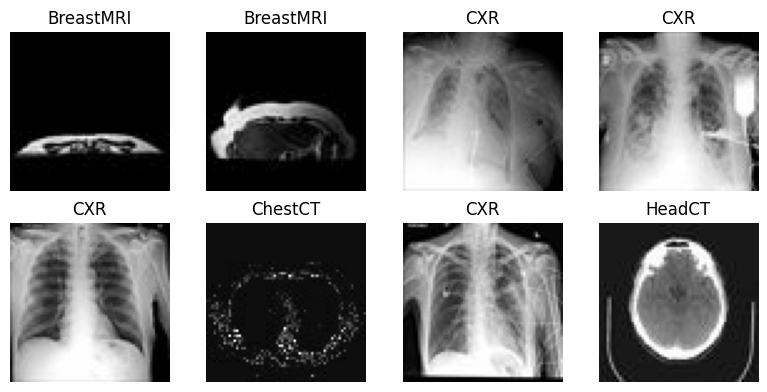

In [5]:
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Flatten Images for ANN Input
This section reshapes each 64×64 image into a single vector for a fully connected network.

In [6]:
X_train_f = X_train.reshape(len(X_train), -1)
X_val_f   = X_val.reshape(len(X_val), -1)
X_test_f  = X_test.reshape(len(X_test), -1)

print("Flattened train shape:", X_train_f.shape)

Flattened train shape: (41267, 4096)


## 7. Build and Compile the ANN
This section defines a simple feed-forward ANN baseline using dense layers and dropout.

In [7]:
def build_ann(input_dim, num_classes):
    """
    Basic feed-forward ANN (fully connected).
    This matches your taught ANN content and acts as a baseline.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    return model

ann = build_ann(X_train_f.shape[1], num_classes)
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,230,534 (8.51 MB)

 Trainable params: 2,230,534 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the ANN
This section trains the ANN with early stopping to avoid overfitting and keep training consistent.

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = ann.fit(
    X_train_f, y_train,
    validation_data=(X_val_f, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9251 - loss: 0.2116 - val_accuracy: 0.9663 - val_loss: 0.0847
Epoch 2/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9640 - loss: 0.1098 - val_accuracy: 0.9916 - val_loss: 0.0391
Epoch 3/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9673 - loss: 0.1049 - val_accuracy: 0.9898 - val_loss: 0.0382
Epoch 4/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9759 - loss: 0.0802 - val_accuracy: 0.9913 - val_loss: 0.0409
Epoch 5/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9656 - loss: 0.0939 - val_accuracy: 0.9785 - val_loss: 0.1097
Epoch 6/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9700 - loss: 0.0875 - val_accuracy: 0.9882 - val_loss: 0.0627
Epoch 7/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9720 - loss: 0.0795 - val_accuracy: 0.9938 - val_loss: 0.0325
Epoch 8/30
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9756 - loss: 0.0639 - val_accuracy: 

## 9. Plot ANN Learning Curves
This section visualises training vs validation loss and accuracy over epochs.

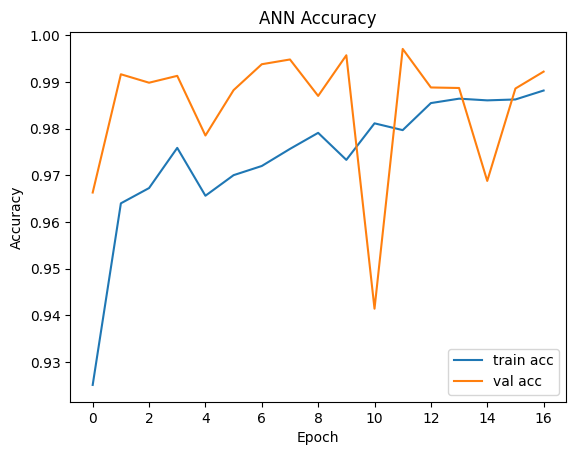

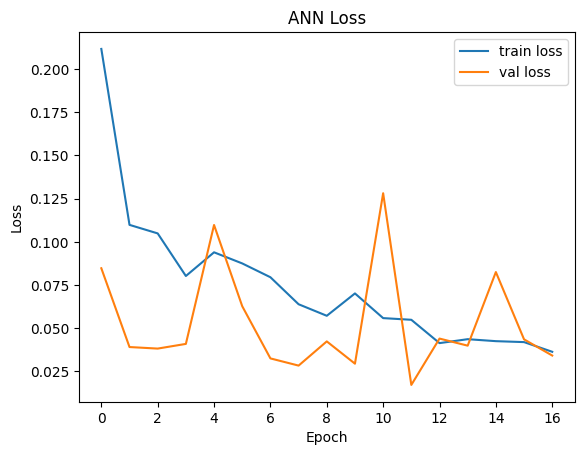

In [9]:
plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 10. Evaluate ANN Performance
This section reports final test metrics and a confusion matrix for later comparison with the CNN.

ANN Test Accuracy: 0.9979
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (ANN):
              precision    recall  f1-score   support

   AbdomenCT       1.00      1.00      1.00      1500
   BreastMRI       1.00      1.00      1.00      1344
         CXR       1.00      0.99      1.00      1500
     ChestCT       1.00      1.00      1.00      1500
        Hand       0.99      1.00      0.99      1500
      HeadCT       1.00      1.00      1.00      1500

    accuracy                           1.00      8844
   macro avg       1.00      1.00      1.00      8844
weighted avg       1.00      1.00      1.00      8844



<Figure size 700x700 with 0 Axes>

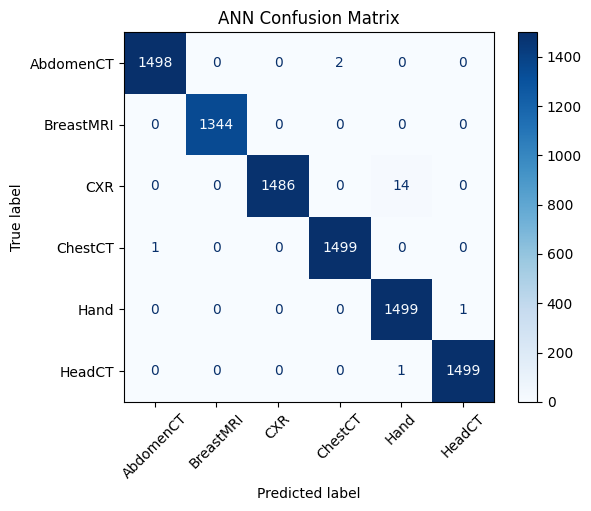

In [10]:
test_loss, test_acc = ann.evaluate(X_test_f, y_test, verbose=0)
print(f"ANN Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(ann.predict(X_test_f), axis=1)

print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

plt.figure(figsize=(7, 7))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("ANN Confusion Matrix")
plt.show()